# Bangla Instruction Dataset — 30K Collection & Quality Pipeline

**Target:** ~30,000 Bangla instruction–response pairs
- **25,000** from the TigerLLM `Bangla-Instruct` dataset (Hugging Face API)
- **5,000** from web scraping / open-source Bangla QnA sources

**Pipeline (5 stages)**
1. Collection & Integration — gather sources → merge → standardize schema
2. Data Cleaning — dedup • Unicode normalization • encoding fix • missing values • text cleanup • language check
3. Quality Validation & Categorization — completeness, consistency, formatting, task type
4. Quality Scoring & Statistics — score each example • dataset-wide analytics
5. Final Export — JSON / CSV output + full documentation

> Runtime: CPU is enough. Run cells top to bottom.

## 0. Setup

In [ ]:
!pip -q install datasets huggingface_hub ftfy rapidfuzz beautifulsoup4 lxml tqdm pandas matplotlib requests
print("done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.1 MB/s eta 0:00:00
done


In [ ]:
import os, re, json, html, random, hashlib, unicodedata, time
from collections import Counter, defaultdict
from pathlib import Path

import pandas as pd
import numpy as np
import requests
from tqdm.auto import tqdm

random.seed(42); np.random.seed(42)

# ----------------------------- CONFIG -----------------------------
CONFIG = {
    "TARGET_TOTAL":        30_000,
    "TARGET_TIGERLLM":     25_000,
    "TARGET_SCRAPED":       5_000,

    # TigerLLM / Bangla-Instruct on the Hugging Face Hub.
    # If the canonical repo id changes, the auto-search cell below will find it.
    "HF_DATASET_CANDIDATES": [
        "md-nishat-008/Bangla-Instruct",
        "md-nishat-008/TigerLLM-Bangla-Instruct",
    ],
    "HF_TOKEN": os.environ.get("HF_TOKEN", ""),   # optional; set for gated repos

    # Open-source Bangla QnA / instruction fallbacks for the 5K "scraped" slice
    "OPEN_QNA_DATASETS": [
        ("csebuetnlp/squad_bn",            "train"),
        ("iamshnoo/alpaca-cleaned-bengali","train"),
        ("OdiaGenAI/all_combined_bengali_252k", "train"),
    ],
    "WIKI_SCRAPE_PAGES":    300,     # Bangla Wikipedia pages to scrape for QnA
    "MIN_BANGLA_RATIO":     0.55,    # language check threshold
    "MIN_INSTR_CHARS":      10,
    "MIN_OUTPUT_CHARS":     20,
    "MAX_OUTPUT_CHARS":     8000,
    "NEAR_DUP_THRESHOLD":   92,      # rapidfuzz ratio (0-100)
    "QUALITY_KEEP_SCORE":   60,      # min score for the "clean/high-quality" export
    "OUT_DIR":              "/content/bangla_instruct_30k",
}

OUT = Path(CONFIG["OUT_DIR"]); OUT.mkdir(parents=True, exist_ok=True)
(OUT / "raw").mkdir(exist_ok=True)
(OUT / "final").mkdir(exist_ok=True)

SCHEMA = ["id", "instruction", "input", "output", "source", "source_type",
          "language", "task_type", "license", "collected_at"]

def new_id(text):
    return hashlib.md5(text.encode("utf-8")).hexdigest()[:16]

print("Config ready ->", OUT)

Config ready -> /content/bangla_instruct_30k


---
## Stage 1 — Collection & Integration
`Gather sources → merge → standardize schema`

### 1a. TigerLLM `Bangla-Instruct` — 25,000 examples via the Hugging Face API

In [ ]:
from huggingface_hub import HfApi, login
from datasets import load_dataset

if CONFIG["HF_TOKEN"]:
    login(CONFIG["HF_TOKEN"])

api = HfApi()

def resolve_tigerllm_repo():
    # 1) try the known ids
    for rid in CONFIG["HF_DATASET_CANDIDATES"]:
        try:
            api.dataset_info(rid)
            return rid
        except Exception:
            pass
    # 2) fall back to a Hub search
    for q in ["Bangla-Instruct", "TigerLLM bangla instruct", "bangla instruction tuning"]:
        hits = list(api.list_datasets(search=q, limit=20))
        for h in hits:
            if "instruct" in h.id.lower() and ("bangla" in h.id.lower() or "bengali" in h.id.lower()):
                return h.id
    return None

TIGER_REPO = resolve_tigerllm_repo()
print("Resolved TigerLLM dataset repo:", TIGER_REPO)

Resolved TigerLLM dataset repo: md-nishat-008/Bangla-Instruct


In [ ]:
def field(row, names):
    for n in names:
        v = row.get(n)
        if isinstance(v, str) and v.strip():
            return v.strip()
    return ""

def load_tigerllm(repo_id, n):
    if repo_id is None:
        print("!! Could not resolve the repo. Set CONFIG['HF_DATASET_CANDIDATES'] manually.")
        return []
    ds = load_dataset(repo_id, split="train")
    print(f"{repo_id}: {len(ds):,} rows | columns = {ds.column_names}")
    if len(ds) > n:
        ds = ds.shuffle(seed=42).select(range(n))
    rows = []
    for r in tqdm(ds, total=len(ds), desc="TigerLLM"):
        instr = field(r, ["instruction", "prompt", "question", "input_text", "query"])
        inp   = field(r, ["input", "context", "passage"])
        outp  = field(r, ["output", "response", "answer", "completion", "target"])
        if not instr or not outp:
            continue
        rows.append({
            "id": new_id(instr + outp),
            "instruction": instr, "input": inp, "output": outp,
            "source": repo_id, "source_type": "api_tigerllm",
            "language": "bn", "task_type": None,
            "license": "cc-by-4.0",
            "collected_at": time.strftime("%Y-%m-%d"),
        })
    return rows

tiger_rows = load_tigerllm(TIGER_REPO, CONFIG["TARGET_TIGERLLM"])
print(f"Collected from TigerLLM: {len(tiger_rows):,}")
pd.DataFrame(tiger_rows).to_json(OUT/"raw"/"tigerllm_raw.jsonl",
                                 orient="records", lines=True, force_ascii=False)

README.md:   0%|          | 0.00/22.5k [00:00<?, ?B/s]

Bangla_INST_400K.csv: reconstructing file:   0%|          |  0.00B /  867MB            

Bangla_INST_400K.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/342391 [00:00<?, ? examples/s]

md-nishat-008/Bangla-Instruct: 342,391 rows | columns = ['instruction', 'response']


TigerLLM:   0%|          | 0/25000 [00:00<?, ?it/s]

Collected from TigerLLM: 25,000


### 1b. 5,000 examples from web scraping + open-source Bangla QnA

In [ ]:
# --- Source A: open-source Bangla QnA datasets on the Hub --------------------
def load_open_qna(target):
    rows = []
    per_source = max(1, target // max(1, len(CONFIG["OPEN_QNA_DATASETS"])))
    for repo, split in CONFIG["OPEN_QNA_DATASETS"]:
        if len(rows) >= target:
            break
        try:
            ds = load_dataset(repo, split=split)
        except Exception as e:
            print(f"skip {repo}: {type(e).__name__}")
            continue
        take = min(per_source, len(ds))
        ds = ds.shuffle(seed=42).select(range(take))
        for r in ds:
            instr = field(r, ["instruction", "question", "prompt"])
            inp   = field(r, ["input", "context", "passage"])
            outp  = field(r, ["output", "answer", "response", "completion"])
            # squad-style answers arrive as a dict/list
            if not outp and isinstance(r.get("answers"), dict):
                a = r["answers"].get("text") or []
                outp = a[0] if a else ""
            if not instr or not outp:
                continue
            rows.append({
                "id": new_id(instr + str(outp)),
                "instruction": instr, "input": inp, "output": str(outp),
                "source": repo, "source_type": "open_qna",
                "language": "bn", "task_type": None,
                "license": "see-source",
                "collected_at": time.strftime("%Y-%m-%d"),
            })
        print(f"{repo}: +{len(rows)} cumulative")
    return rows[:target]

In [ ]:
# --- Source B: live web scraping (Bangla Wikipedia -> QnA pairs) -------------
from bs4 import BeautifulSoup

WIKI_API = "https://bn.wikipedia.org/w/api.php"
HEADERS  = {"User-Agent": "BanglaInstructResearch/1.0 (academic thesis dataset collection)"}

def wiki_random_titles(n):
    titles, got = [], 0
    while got < n:
        batch = min(50, n - got)
        r = requests.get(WIKI_API, headers=HEADERS, timeout=30, params={
            "action": "query", "list": "random", "rnnamespace": 0,
            "rnlimit": batch, "format": "json"})
        titles += [x["title"] for x in r.json()["query"]["random"]]
        got = len(titles); time.sleep(0.3)
    return titles

def wiki_extract(title):
    r = requests.get(WIKI_API, headers=HEADERS, timeout=30, params={
        "action": "query", "prop": "extracts", "explaintext": 1,
        "titles": title, "format": "json"})
    pages = r.json()["query"]["pages"]
    return next(iter(pages.values())).get("extract", "")

QUESTION_TEMPLATES = [
    "{t} সম্পর্কে সংক্ষেপে ব্যাখ্যা করুন।",
    "{t} কী? বিস্তারিত লিখুন।",
    "{t} বিষয়ে একটি অনুচ্ছেদ লিখুন।",
    "{t} সম্পর্কে গুরুত্বপূর্ণ তথ্যগুলো উল্লেখ করুন।",
]

def scrape_wikipedia(n_pages, per_page=2):
    rows, titles = [], wiki_random_titles(n_pages)
    for t in tqdm(titles, desc="bn.wikipedia"):
        try:
            text = wiki_extract(t)
        except Exception:
            continue
        paras = [p.strip() for p in text.split("\n") if len(p.strip()) > 200]
        for p in paras[:per_page]:
            instr = random.choice(QUESTION_TEMPLATES).format(t=t)
            rows.append({
                "id": new_id(instr + p[:200]),
                "instruction": instr, "input": "", "output": p[:2000],
                "source": f"bn.wikipedia.org/wiki/{t}", "source_type": "web_scrape",
                "language": "bn", "task_type": None,
                "license": "CC-BY-SA-4.0",
                "collected_at": time.strftime("%Y-%m-%d"),
            })
        time.sleep(0.2)
    return rows

In [ ]:
TARGET_B = CONFIG["TARGET_SCRAPED"]

open_rows = load_open_qna(int(TARGET_B * 0.7))          # ~3,500 from open QnA
need      = TARGET_B - len(open_rows)
scraped   = scrape_wikipedia(CONFIG["WIKI_SCRAPE_PAGES"]) if need > 0 else []
scraped   = scraped[:need]

secondary_rows = open_rows + scraped
print(f"open QnA: {len(open_rows):,} | scraped: {len(scraped):,} | total: {len(secondary_rows):,}")
pd.DataFrame(secondary_rows).to_json(OUT/"raw"/"secondary_raw.jsonl",
                                     orient="records", lines=True, force_ascii=False)

README.md:   0%|          | 0.00/9.17k [00:00<?, ?B/s]

squad_bn.py:   0%|          | 0.00/3.94k [00:00<?, ?B/s]

skip csebuetnlp/squad_bn: RuntimeError


README.md:   0%|          | 0.00/499 [00:00<?, ?B/s]

data/train-00000-of-00001-258f7b77b36023(…): reconstructing file:   0%|          |  0.00B / 31.1MB            

...

bengali_hardcode_mix_qa_252k.json:   0%|          | 0.00/309M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/252622 [00:00<?, ? examples/s]

OdiaGenAI/all_combined_bengali_252k: +2332 cumulative


bn.wikipedia:   0%|          | 0/300 [00:00<?, ?it/s]

open QnA: 2,332 | scraped: 23 | total: 2,355


### 1c. Merge & standardize schema

In [ ]:
df = pd.DataFrame(tiger_rows + secondary_rows)
for c in SCHEMA:
    if c not in df.columns:
        df[c] = None
df = df[SCHEMA]
df["input"]  = df["input"].fillna("")
df["output"] = df["output"].fillna("")

print(f"MERGED: {len(df):,} rows")
display(df["source_type"].value_counts())
df.to_json(OUT/"raw"/"stage1_merged.jsonl", orient="records", lines=True, force_ascii=False)
df.head(3)

MERGED: 27,355 rows


,count
source_type,
api_tigerllm,25000
open_qna,2332
web_scrape,23


,id,instruction,input,output,source,source_type,language,task_type,license,collected_at
0,8c895133d3c2f9e2,গুগলের সিইও কে?,,গুগলের সিইও হলেন সন্দর্শ পিচাই (Sundar Pichai)...,md-nishat-008/Bangla-Instruct,api_tigerllm,bn,None,cc-by-4.0,2026-09-19
1,d395bfdb3f1a083b,কিভাবে সহজ চকোলেট গানাচে তৈরি করবেন সহজ চকোলেট...,,"হ্যাঁ, এই বাক্যটি একটি অর্থবহ নির্দেশনা। এটি স...",md-nishat-008/Bangla-Instruct,api_tigerllm,bn,None,cc-by-4.0,2026-09-19
2,17bf375f1a37b618,একটা পরিবার পাহাড়ে ক্যাম্পিং করতে যায়। এরপর ...,,একটি পরিবারের পাহাড়ে ক্যাম্পিং এর অভিজ্ঞতা নি...,md-nishat-008/Bangla-Instruct,api_tigerllm,bn,None,cc-by-4.0,2026-09-19


---
## Stage 2 — Data Cleaning
`Dedup • Unicode normalization • encoding fix • missing values • text cleanup • language check`

In [ ]:
import ftfy
from rapidfuzz import fuzz, process as rf_process

BANGLA_RE  = re.compile(r"[\u0980-\u09FF]")
ZERO_WIDTH = re.compile(r"[\u200b\u200c\u200d\ufeff\u00ad]")
MULTISPACE = re.compile(r"[ \t\u00a0]+")
HTML_TAG   = re.compile(r"<[^>]+>")
URL_RE     = re.compile(r"https?://\S+|www\.\S+")

def clean_text(s):
    if not isinstance(s, str):
        return ""
    s = ftfy.fix_text(s)                       # encoding / mojibake fix
    s = html.unescape(s)
    s = HTML_TAG.sub(" ", s)                   # strip stray markup
    s = unicodedata.normalize("NFC", s)        # Unicode normalization
    s = ZERO_WIDTH.sub("", s)
    s = URL_RE.sub("<URL>", s)
    s = MULTISPACE.sub(" ", s)
    s = re.sub(r"\n{3,}", "\n\n", s)
    return s.strip()

def bangla_ratio(s):
    letters = [ch for ch in s if ch.isalpha()]
    if not letters:
        return 0.0
    return sum(bool(BANGLA_RE.match(ch)) for ch in letters) / len(letters)

log = {}
n0 = len(df)

# --- normalize + encoding fix + text cleanup --------------------------------
for col in ["instruction", "input", "output"]:
    df[col] = [clean_text(x) for x in tqdm(df[col], desc=f"clean:{col}")]

# --- missing / too-short / too-long values ----------------------------------
mask = (df["instruction"].str.len() >= CONFIG["MIN_INSTR_CHARS"]) & \
       (df["output"].str.len().between(CONFIG["MIN_OUTPUT_CHARS"], CONFIG["MAX_OUTPUT_CHARS"]))
log["dropped_missing_or_length"] = int((~mask).sum()); df = df[mask].copy()

# --- language check ----------------------------------------------------------
df["bn_ratio_instruction"] = df["instruction"].map(bangla_ratio)
df["bn_ratio_output"]      = df["output"].map(bangla_ratio)
lang_ok = (df[["bn_ratio_instruction", "bn_ratio_output"]].min(axis=1) >= CONFIG["MIN_BANGLA_RATIO"])
log["dropped_language_check"] = int((~lang_ok).sum()); df = df[lang_ok].copy()

print(json.dumps(log, indent=2)); print(f"{n0:,} -> {len(df):,}")

clean:instruction:   0%|          | 0/27355 [00:00<?, ?it/s]

clean:input:   0%|          | 0/27355 [00:00<?, ?it/s]

clean:output:   0%|          | 0/27355 [00:00<?, ?it/s]

{
  "dropped_missing_or_length": 80,
  "dropped_language_check": 6472
}
27,355 -> 20,803


In [ ]:
# --- exact duplicates --------------------------------------------------------
df["_key"] = (df["instruction"] + " ||| " + df["input"] + " ||| " + df["output"]).map(
    lambda s: hashlib.md5(s.encode()).hexdigest())
before = len(df); df = df.drop_duplicates("_key").copy()
log["dropped_exact_dup"] = before - len(df)

# --- near-duplicate instructions (blocked by prefix to stay O(n) friendly) ---
def drop_near_dupes(frame, threshold):
    keep, seen_block = [], defaultdict(list)
    for idx, text in tqdm(frame["instruction"].items(), total=len(frame), desc="near-dup"):
        block = text[:12]                       # cheap blocking key
        pool  = seen_block[block]
        if pool and rf_process.extractOne(text, pool, scorer=fuzz.ratio)[1] >= threshold:
            continue
        pool.append(text); keep.append(idx)
    return frame.loc[keep]

before = len(df)
df = drop_near_dupes(df, CONFIG["NEAR_DUP_THRESHOLD"]).copy()
log["dropped_near_dup"] = before - len(df)
df = df.drop(columns=["_key"])

print(json.dumps(log, indent=2)); print(f"CLEAN: {len(df):,} rows")
df.to_json(OUT/"raw"/"stage2_clean.jsonl", orient="records", lines=True, force_ascii=False)

near-dup:   0%|          | 0/20756 [00:00<?, ?it/s]

{
  "dropped_missing_or_length": 80,
  "dropped_language_check": 6472,
  "dropped_exact_dup": 47,
  "dropped_near_dup": 136
}
CLEAN: 20,620 rows


---
## Stage 3 — Quality Validation & Categorization
`Completeness, consistency, formatting, task type`

In [ ]:
TASK_RULES = [
    ("summarization",   ["সারসংক্ষেপ", "সংক্ষেপে", "সারাংশ", "সংক্ষিপ্ত কর"]),
    ("translation",     ["অনুবাদ", "ইংরেজিতে", "বাংলায় অনুবাদ"]),
    ("question_answering", ["কে ", "কী", "কি ", "কেন", "কোথায়", "কখন", "কত", "কোন"]),
    ("code",            ["কোড", "প্রোগ্রাম", "ফাংশন", "python", "def ", "```"]),
    ("math",            ["গণনা", "হিসাব", "সমাধান কর", "যোগফল", "গাণিতিক"]),
    ("classification",  ["শ্রেণীবদ্ধ", "ভাগ কর", "চিহ্নিত কর", "শনাক্ত"]),
    ("creative_writing",["গল্প", "কবিতা", "রচনা", "চিঠি", "কল্পনা"]),
    ("explanation",     ["ব্যাখ্যা", "বর্ণনা", "বুঝিয়ে", "আলোচনা"]),
    ("list_generation", ["তালিকা", "উল্লেখ কর", "নাম লিখ"]),
]

def classify_task(instr, outp):
    low = instr.lower()
    for name, keys in TASK_RULES:
        if any(k.lower() in low for k in keys):
            return name
    return "open_ended"

def check_completeness(r):
    return bool(r["instruction"]) and bool(r["output"]) and len(r["output"].split()) >= 5

def check_consistency(r):
    # output should not merely echo the instruction, nor look truncated
    if fuzz.ratio(r["instruction"], r["output"]) > 85:
        return False
    if r["output"].rstrip().endswith((",", "-", "এবং", "ও")):
        return False
    return True

def check_formatting(r):
    o = r["output"]
    if o != o.strip():                       return False
    if re.search(r"(.)\1{9,}", o):           return False   # character spam
    if o.count("<URL>") > 3:                 return False
    if re.search(r"[\u0980-\u09FF]{200,}", o.replace(" ", "")):
        return False                                        # unsegmented wall of text
    return True

tqdm.pandas(desc="validate")
df["task_type"]      = df.progress_apply(lambda r: classify_task(r["instruction"], r["output"]), axis=1)
df["is_complete"]    = df.apply(check_completeness, axis=1)
df["is_consistent"]  = df.apply(check_consistency, axis=1)
df["is_well_formed"] = df.apply(check_formatting, axis=1)
df["valid"]          = df["is_complete"] & df["is_consistent"] & df["is_well_formed"]

print(df[["is_complete", "is_consistent", "is_well_formed", "valid"]].mean().round(4).to_string())
display(df["task_type"].value_counts())

validate:   0%|          | 0/20620 [00:00<?, ?it/s]

is_complete       0.9980
is_consistent     0.9982
is_well_formed    0.9923
valid             0.9885


,count
task_type,
question_answering,15260
open_ended,3268
explanation,561
summarization,352
math,324
code,251
list_generation,247
creative_writing,160
classification,139


---
## Stage 4 — Quality Scoring & Statistics
`Score each example • compute dataset-wide analytics`

In [ ]:
def length_score(n_words, lo=15, hi=400):
    if n_words < 5:   return 0.0
    if n_words < lo:  return n_words / lo
    if n_words <= hi: return 1.0
    return max(0.3, hi / n_words)

def lexical_diversity(text):
    w = text.split()
    return len(set(w)) / len(w) if w else 0.0

WEIGHTS = {"completeness": 25, "consistency": 20, "formatting": 15,
           "language": 15, "length": 15, "diversity": 10}

def score_row(r):
    n_words = len(r["output"].split())
    parts = {
        "completeness": 1.0 if r["is_complete"] else 0.0,
        "consistency":  1.0 if r["is_consistent"] else 0.0,
        "formatting":   1.0 if r["is_well_formed"] else 0.0,
        "language":     min(1.0, r["bn_ratio_output"] / 0.9),
        "length":       length_score(n_words),
        "diversity":    min(1.0, lexical_diversity(r["output"]) / 0.6),
    }
    return round(sum(parts[k] * WEIGHTS[k] for k in WEIGHTS), 2)

df["output_words"]  = df["output"].str.split().str.len()
df["instr_words"]   = df["instruction"].str.split().str.len()
df["quality_score"] = df.apply(score_row, axis=1)
df["quality_tier"]  = pd.cut(df["quality_score"], [-1, 50, 70, 85, 101],
                             labels=["low", "medium", "high", "excellent"])

stats = {
    "total_examples":     int(len(df)),
    "valid_examples":     int(df["valid"].sum()),
    "by_source_type":     df["source_type"].value_counts().to_dict(),
    "by_task_type":       df["task_type"].value_counts().to_dict(),
    "by_quality_tier":    df["quality_tier"].value_counts().to_dict(),
    "quality_score":      df["quality_score"].describe().round(2).to_dict(),
    "output_words":       df["output_words"].describe().round(2).to_dict(),
    "instruction_words":  df["instr_words"].describe().round(2).to_dict(),
    "mean_bangla_ratio":  round(float(df["bn_ratio_output"].mean()), 4),
    "unique_instructions": int(df["instruction"].nunique()),
}
print(json.dumps(stats, indent=2, ensure_ascii=False, default=str))

{
  "total_examples": 20620,
  "valid_examples": 20383,
  "by_source_type": {
    "api_tigerllm": 18859,
    "open_qna": 1741,
    "web_scrape": 20
  },
  "by_task_type": {
    "question_answering": 15260,
    "open_ended": 3268,
    "explanation": 561,
    "summarization": 352,
    "math": 324,
    "code": 251,
    "list_generation": 247,
    "creative_writing": 160,
    "classification": 139,
    "translation": 58
  },
  "by_quality_tier": {
    "excellent": 20377,
    "high": 199,
    "medium": 43,
    "low": 1
  },
  "quality_score": {
    "count": 20620.0,
    "mean": 98.75,
    "std": 3.16,
    "min": 45.0,
    "25%": 98.88,
    "50%": 100.0,
    "75%": 100.0,
    "max": 100.0
  },
  "output_words": {
    "count": 20620.0,
    "mean": 155.6,
    "std": 88.41,
    "min": 1.0,
    "25%": 106.0,
    "50%": 134.0,
    "75%": 200.25,
    "max": 859.0
  },
  "instruction_words": {
    "count": 20620.0,
    "mean": 29.13,
    "std": 20.61,
    "min": 1.0,
    "25%": 13.0,
    "50%": 28.

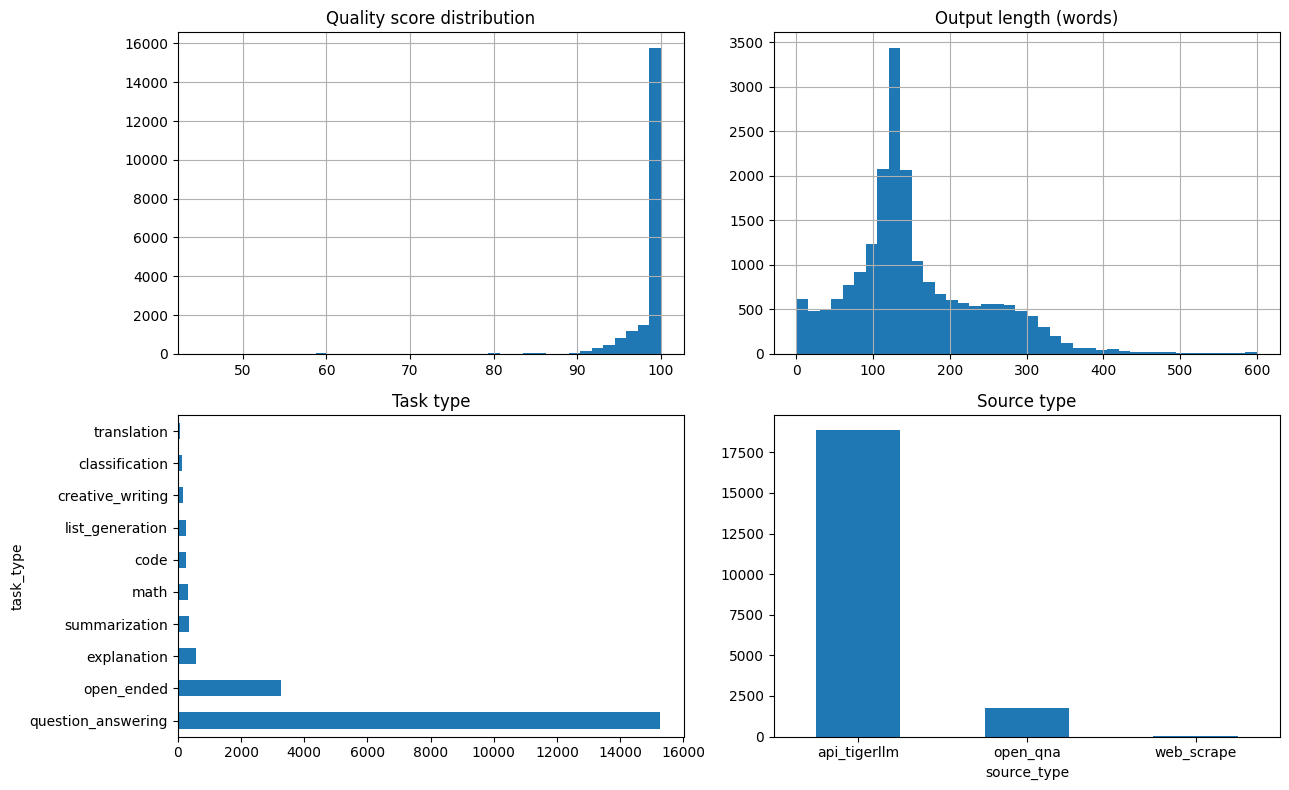

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(13, 8))
df["quality_score"].hist(bins=40, ax=ax[0][0]); ax[0][0].set_title("Quality score distribution")
df["output_words"].clip(upper=600).hist(bins=40, ax=ax[0][1]); ax[0][1].set_title("Output length (words)")
df["task_type"].value_counts().plot.barh(ax=ax[1][0]); ax[1][0].set_title("Task type")
df["source_type"].value_counts().plot.bar(ax=ax[1][1], rot=0); ax[1][1].set_title("Source type")
plt.tight_layout(); plt.savefig(OUT/"final"/"dataset_statistics.png", dpi=150); plt.show()

---
## Stage 5 — Final Export
`JSON / CSV output + full documentation`

In [ ]:
final = df[df["valid"] & (df["quality_score"] >= CONFIG["QUALITY_KEEP_SCORE"])].copy()
final = final.sort_values("quality_score", ascending=False).reset_index(drop=True)

export_cols = SCHEMA + ["quality_score", "quality_tier", "output_words", "bn_ratio_output"]
final_out = final[export_cols]

base = OUT / "final"
final_out.to_json(base/"bangla_instruct_30k.json",  orient="records", indent=2, force_ascii=False)
final_out.to_json(base/"bangla_instruct_30k.jsonl", orient="records", lines=True, force_ascii=False)
final_out.to_csv(base/"bangla_instruct_30k.csv", index=False, encoding="utf-8-sig")

# rejected pool — useful evidence for a data-quality-filtering study
df[~df.index.isin(final.index)].to_json(base/"rejected_examples.jsonl",
                                        orient="records", lines=True, force_ascii=False)

# train / val / test split (90 / 5 / 5)
shuf = final_out.sample(frac=1, random_state=42).reset_index(drop=True)
n = len(shuf); a, b = int(n*0.90), int(n*0.95)
for name, part in [("train", shuf[:a]), ("validation", shuf[a:b]), ("test", shuf[b:])]:
    part.to_json(base/f"{name}.jsonl", orient="records", lines=True, force_ascii=False)
    print(f"{name}: {len(part):,}")

with open(base/"statistics.json", "w", encoding="utf-8") as f:
    json.dump({"pipeline_log": log, "statistics": stats,
               "final_kept": int(len(final))}, f, indent=2, ensure_ascii=False, default=str)
print(f"\nFINAL EXPORT: {len(final_out):,} examples")

train: 18,344
validation: 1,019
test: 1,020

FINAL EXPORT: 20,383 examples


In [ ]:
NL = chr(10)
src_tbl  = NL.join(f"| {k} | {v:,} |" for k, v in final_out["source_type"].value_counts().items())
log_tbl  = NL.join(f"- {k}: {v:,}" for k, v in log.items())
tier_tbl = NL.join(f"- {k}: {v:,}" for k, v in final_out["quality_tier"].value_counts().items())

CARD = f"""# Bangla Instruction Dataset (30K)

**Built:** {time.strftime('%Y-%m-%d')} | **Language:** Bengali (bn) | **Final size:** {len(final_out):,}

## Composition
| Source type | Count |
|---|---|
{src_tbl}

- ~{CONFIG['TARGET_TIGERLLM']:,} target examples from **TigerLLM / Bangla-Instruct** (`{TIGER_REPO}`), pulled via the Hugging Face API.
- ~{CONFIG['TARGET_SCRAPED']:,} target examples from open-source Bangla QnA datasets and Bangla Wikipedia scraping.

## Schema
`id, instruction, input, output, source, source_type, language, task_type, license, collected_at, quality_score, quality_tier, output_words, bn_ratio_output`

## Pipeline
1. **Collection & Integration** - multi-source gather, merge, schema standardization.
2. **Data Cleaning** - ftfy encoding repair, Unicode NFC normalization, zero-width stripping, HTML/URL cleanup, missing-value and length filters, Bangla-script ratio check (>= {CONFIG['MIN_BANGLA_RATIO']}), exact dedup (MD5) and near-dup removal (rapidfuzz >= {CONFIG['NEAR_DUP_THRESHOLD']}).
3. **Quality Validation & Categorization** - completeness, instruction/output consistency, formatting checks; rule-based task-type labels.
4. **Quality Scoring** - weighted 0-100 score over completeness (25), consistency (20), formatting (15), language purity (15), length (15), lexical diversity (10).
5. **Export** - JSON / JSONL / CSV, 90/5/5 splits, rejected pool, statistics, this card.

## Filtering outcome
{log_tbl}
- kept (valid and score >= {CONFIG['QUALITY_KEEP_SCORE']}): {len(final_out):,}

## Quality tiers
{tier_tbl}

## Licensing
Per-record licenses are kept in the `license` column. TigerLLM / Bangla-Instruct is CC-BY-4.0; Wikipedia text is CC-BY-SA-4.0. Check each upstream source before redistribution.

## Limitations
Task-type labels are keyword-based, not model-verified. Scraped Wikipedia pairs are template-generated instructions over encyclopedic paragraphs and are stylistically narrower than the self-instruct data. Quality scores are heuristic proxies, not human judgements.
"""

(base / "DATASET_CARD.md").write_text(CARD, encoding="utf-8")
print(CARD[:1500])

NameError: name 'final_out' is not defined

## Interactive EDA Report

Generates a standalone, clickable HTML report (`eda_report.html`) with distributions,
correlations, missing-value maps, and sample rows for the final exported dataset.
Open it in any browser — no server needed.

In [ ]:
!pip -q install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.9 MB/s eta 0:00:00


In [ ]:
from ydata_profiling import ProfileReport

eda_cols = ["instruction", "input", "output", "source_type", "task_type",
            "language", "quality_score", "quality_tier", "output_words",
            "instr_words", "bn_ratio_output"]
eda_df = final_out.reindex(columns=[c for c in eda_cols if c in final_out.columns]).copy()

profile = ProfileReport(
    eda_df,
    title="Bangla Instruction Dataset - Interactive EDA",
    explorative=True,
    minimal=False,
)

eda_path = base / "eda_report.html"
profile.to_file(eda_path)
print("EDA report written ->", eda_path)

try:
    from google.colab import files
    files.download(str(eda_path))
except Exception:
    pass

/tmp/ipykernel_755/331132274.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:18<00:00,  1.87s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

EDA report written -> /content/bangla_instruct_30k/final/eda_report.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil
zip_path = shutil.make_archive("/content/bangla_instruct_30k", "zip", str(base))
print("Zipped ->", zip_path)

for p in sorted(base.iterdir()):
    print(f"{p.name:35s} {p.stat().st_size/1e6:8.2f} MB")

try:
    from google.colab import files
    files.download(zip_path)
except Exception as e:
    print("(download only works inside Colab)", e)

Zipped -> /content/bangla_instruct_30k.zip
DATASET_CARD.md                         0.00 MB
bangla_instruct_30k.csv                60.38 MB
bangla_instruct_30k.json               66.28 MB
bangla_instruct_30k.jsonl              64.73 MB
dataset_statistics.png                  0.12 MB
rejected_examples.jsonl                15.57 MB
statistics.json                         0.00 MB
test.jsonl                              3.28 MB
train.jsonl                            58.14 MB
validation.jsonl                        3.31 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>